In [92]:
import os, glob
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pctk import multicellds

from scipy.spatial.distance import pdist
from scipy.spatial import ConvexHull
from sklearn.linear_model import LinearRegression

from matplotlib.colors import Normalize
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm



# !pip install git+https://github.com/migp11/pctk

In [93]:
################################################################################
# Calculations
################################################################################

def compute_diameter_hull(df):
    diameters = []

    for t, group in df.groupby("time"):
        coords = group[["x_position", "y_position"]].values

        if len(coords) < 3:
            diam = pdist(coords).max() if len(coords) > 1 else 0.0
        else:
            hull = ConvexHull(coords)
            hull_points = coords[hull.vertices]
            diam = pdist(hull_points).max()

        diameters.append((t, diam))

    return pd.DataFrame(diameters, columns=["time", "diameter"])


# ---- Estimate exponential growth rate ----
def estimate_growth_rate(diam_df):
    # remove zeros (log issue)
    diam_df = diam_df[diam_df["diameter"] > 0].copy()

    X = diam_df["time"].values.reshape(-1, 1)
    y = np.log(diam_df["diameter"].values)

    model = LinearRegression().fit(X, y)
    mu_D = model.coef_[0]

    return mu_D, model


# ---- Full pipeline ----
def compute_diameter_growth_rate(df, method="hull"):
    if method == "hull":
        diam_df = compute_diameter_hull(df)
    else:
        diam_df = compute_diameter_maxdist(df)

    mu_D, model = estimate_growth_rate(diam_df)

    return mu_D, diam_df, model

In [94]:
def plot_cells_svg(
                    df,
                    time_point,
                    color_config,
                    X_MIN=-250, X_MAX=250,
                    Y_MIN=-250, Y_MAX=250,
                    xlim=None,
                    ylim=None,
                    skip_dead=True,
                    scale_bar_length = 50,
                    colorbar_range=None,
                    linewidth=0.5,
                    hide_axis=False,
                    normalize_colors=True,
                    vmax=None,
                    vmin=None,
                    edgecolor=None
                ):


    df_t = df[df["time"] == time_point].copy()
    df_t = df_t.loc[:, ~df_t.columns.duplicated()]

    if skip_dead:
        df_t = df_t[df_t['dead']==False]

    # --- Cropping ---
    if xlim is not None:
        df_t = df_t[(df_t["x_position"] >= xlim[0]) &
                    (df_t["x_position"] <= xlim[1])]
    if ylim is not None:
        df_t = df_t[(df_t["y_position"] >= ylim[0]) &
                    (df_t["y_position"] <= ylim[1])]

    # --- Radius ---
    volume = df_t["total_volume"].values
    radius = np.cbrt((3 * volume) / (4 * np.pi))

    fig, ax = plt.subplots(figsize=(6, 6))

    cmap = color_config["cmap"]
    value_fn = color_config["value_fn"]


    if normalize_colors:
        values = np.array([value_fn(row) for i,row in df_t.iterrows() if row.dead == 0])
        if vmax is None:
            vmax = values.max()
        if vmin is None:
            vmin = values.min()
        if vmin < 0 and vmax > 0:
            norm = TwoSlopeNorm(
                vmin=vmin,
                vcenter=0.0,
                vmax=vmax
            )
        else:
            norm = Normalize(vmin=vmin, vmax=vmax)

    values = []

    for row, r in zip(df_t.itertuples(), radius):
        x, y = row.x_position, row.y_position

        if row.dead == 1:
            color = "saddlebrown"
            values.append(np.nan)  # exclude from colorbar
        elif row.y_death_rates > 0:
            color = "grey"
            values.append(np.nan)
        else:
            v = value_fn(row)
            if normalize_colors:
                color = cmap(norm(v))
            else:
                color = cmap(v)
            values.append(v)

        # Per-cell edge color defaults to the cell's own fill color (seamless
        # outline) without permanently overwriting the shared `edgecolor` arg.
        cell_edgecolor = color if edgecolor is None else edgecolor

        circle = plt.Circle(
            (x, y), r,
            facecolor=color,
            edgecolor=cell_edgecolor,
            linewidth=linewidth
        )
        ax.add_patch(circle)


    # --- Limits ---
    ax.set_xlim(xlim if xlim else (X_MIN, X_MAX))
    ax.set_ylim(ylim if ylim else (Y_MIN, Y_MAX))
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    if hide_axis:
        ax.axis("off")

    # --- Colorbar ---
    if color_config.get("show_colorbar", True):
        sm = plt.cm.ScalarMappable(cmap=cmap)
        sm.set_array([v for v in values if not np.isnan(v)])
        if colorbar_range is not None:
            sm.set_clim(*colorbar_range)

        cbar = fig.add_axes([0.92, 0.18, 0.03, 0.6])
        cb = fig.colorbar(sm, cax=cbar)

        cbar.set_ylabel(color_config.get("label", ""), fontsize=18)


    # Get axis width in data units
    x0, x1 = ax.get_xlim()
    axis_width_data = x1 - x0

    # --- Scale bar (fixed position, correct length) ---
    # µm

    # Convert to fraction of axis width
    bar_fraction = scale_bar_length / axis_width_data

    # Get axis position in figure coordinates
    bbox = ax.get_position()

    # Place bar just below the axes
    #x_start = bbox.x0 + 0.05 * bbox.width
    x_end = bbox.x1 - 0.05 * bbox.width
    y_start = bbox.y0 - 0.025

    # Draw using figure transform
    fig.lines.append(plt.Line2D(
        [x_end - bar_fraction * bbox.width, x_end ],
        [y_start, y_start],
        transform=fig.transFigure,
        color="black",
        linewidth=3,
        solid_capstyle="butt"
    ))

    # Label
    fig.text(
        x_end - (bar_fraction * bbox.width) / 2,
        y_start - 0.02,
        f"{scale_bar_length} µm",
        ha="center",
        va="top",
        fontsize=18
    )

    if time_point == 1:
        time_label = f"Time = {time_point} hour"
    else:
        time_label = f"Time = {time_point} hours"

    # ax.text(
    #     0.65, 0.98,
    #     time_label,
    #     transform=ax.transAxes,
    #     ha="left",
    #     va="top",
    #     fontsize=14
    # )


    return fig

In [95]:
_DROP_COLS = [
    "cytoplasmic_biomass_change_rate",
    "nuclear_biomass_change_rate",
    "fluid_change_rate",
    "calcification_rate",
    "target_solid_cytoplasmic",
    "target_solid_nuclear",
    "target_fluid_fraction",
    "radius",
    "surface_area",
    "cell_cell_adhesion_strength",
    "cell_BM_adhesion_strength",
    "cell_cell_repulsion_strength",
    "cell_BM_repulsion_strength",
    "cell_adhesion_affinities",
    "relative_maximum_adhesion_distance",
    "maximum_number_of_attachments",
    "attachment_elastic_constant",
    "attachment_rate",
    "detachment_rate",
    "is_motile",
    "persistence_time",
    "migration_speed",
]


def _get_simplified_labels_node(tree):
    root = tree.getroot()
    cellular_info = root.find("cellular_information")
    if cellular_info is None:
        raise ValueError("cellular_information node not found in MultiCellDS XML")

    def _walk(node):
        for child in node:
            if child.tag == "simplified_data" and child.attrib.get("source") == "PhysiCell":
                return child.find("labels")
            labels = _walk(child)
            if labels is not None:
                return labels
        return None

    labels = _walk(cellular_info)
    if labels is None:
        raise ValueError("PhysiCell simplified_data labels not found in MultiCellDS XML")
    return labels


def cell_column_names_from_tree(tree, sep="_"):
    labels = _get_simplified_labels_node(tree)
    n_cols = max(
        int(label.attrib["index"]) + int(label.attrib["size"]) for label in labels
    )
    columns = [None] * n_cols
    for label in labels:
        name = label.text
        idx = int(label.attrib["index"])
        size = int(label.attrib["size"])
        if size == 1:
            columns[idx] = name
        elif size == 2:
            for i, axis in enumerate(["x", "y"]):
                columns[idx + i] = f"{axis}{sep}{name}"
        elif size == 3:
            for i, axis in enumerate(["x", "y", "z"]):
                columns[idx + i] = f"{axis}{sep}{name}"
        else:
            for i in range(size):
                columns[idx + i] = f"{name}_{i}"
    for i, col in enumerate(columns):
        if col is None:
            columns[i] = f"col_{i}"
    return columns


def read_cells(reader, drop_cols=None, time_interval=60, max_time=-1):
    if drop_cols is None:
        drop_cols = _DROP_COLS
    df_list = []
    col_names = cell_column_names_from_tree(reader._tree)
    xml_list = sorted(glob.glob(os.path.join(reader._output_folder, "output*.xml")))
    for xml_fname in xml_list:
        tree = ET.parse(xml_fname)
        cell_matrix = reader.get_cells_matrix(tree)
        df = pd.DataFrame(cell_matrix, columns=col_names)
        if "ID" in df.columns:
            df = df.set_index("ID")
        t = reader.get_time(tree)
        df = df.assign(time=float(t))
        if drop_cols:
            df = df.drop(
                columns=[c for c in drop_cols if c in df.columns], errors="ignore"
            )
        df_list.append(df)
        if max_time > 0 and t >= max_time:
            break
    df_cells = pd.concat(df_list)
    df_cells.loc[:, "time"] /= time_interval
    return df_cells


def read_microenvironment_step(reader, time_step=None, z_slice = 0,
                               convert_to_hours=True, time_interval=30):
    t_current, menv = None, None

    for t, a in reader.microenvironment_as_matrix_iterator():
        if convert_to_hours:
            t /= time_interval

        t_current, menv = t, a
        if t == time_step:
            break

    if time_step is None:
        print(f"Empty or incorrect time step returning microenviroment at last time step {t_current}")

    # ── Coordinate arrays ─────────────────────────────────────────────────────────
    x = menv[0, :]   # row 0 → x
    y = menv[1, :]   # row 1 → y
    z = menv[2, :]   # row 2 → z
    # row 3 → voxel volume; rows 4+ → substrate concentrations

    mask = z == z_slice

    # ── Build a tidy DataFrame for this slice ────────────────────────────────────────────
    substrate_info = reader.microenvironment_columns

    df_micro = pd.DataFrame({"x": x[mask], "y": y[mask]})
    for name, _, str_idx in substrate_info:
        df_micro[name] = menv[4 + int(str_idx), mask]

    return df_micro

In [96]:
usless_columns = ['z_position', 'current_phase', 'current_death_model',
                  'nuclear_volume', 'cytoplasmic_volume', 'fluid_fraction', 'calcified_fraction', 'x_orientation', 'y_orientation',
                  'z_orientation', 'polarity', 'x_velocity', 'y_velocity', 'z_velocity', 'number_of_nuclei', 'total_attack_time',
                  'contact_with_basement_membrane', 'current_cycle_phase_exit_rate', 'cytoplasmic_biomass_change_rate',
                  'nuclear_biomass_change_rate', 'fluid_change_rate', 'calcification_rate', 'target_solid_cytoplasmic',
                  'target_solid_nuclear', 'target_fluid_fraction', 'radius', 'nuclear_radius', 'surface_area',
                  'cell_cell_adhesion_strength', 'cell_BM_adhesion_strength', 'cell_cell_repulsion_strength',
                  'cell_BM_repulsion_strength', 'cell_adhesion_affinities', 'relative_maximum_adhesion_distance',
                  'maximum_number_of_attachments', 'attachment_elastic_constant', 'attachment_rate', 'detachment_rate',
                  'is_motile', 'persistence_time', 'migration_speed', 'x_migration_bias_direction', 'y_migration_bias_direction',
                  'z_migration_bias_direction', 'migration_bias', 'x_motility_vector', 'y_motility_vector', 'z_motility_vector',
                  'chemotaxis_index', 'chemotaxis_direction', 'z_chemotactic_sensitivities', 'z_chemotactic_sensitivities',
                  'z_chemotactic_sensitivities', 'z_chemotactic_sensitivities', 'z_chemotactic_sensitivities', 'z_secretion_rates',
                  'z_secretion_rates', 'z_secretion_rates', 'z_secretion_rates', 'z_secretion_rates', 'z_uptake_rates', 'z_uptake_rates',
                  'z_uptake_rates', 'z_uptake_rates', 'z_uptake_rates', 'z_saturation_densities', 'z_saturation_densities',
                  'z_saturation_densities', 'z_saturation_densities', 'z_saturation_densities', 'z_net_export_rates',
                  'z_net_export_rates', 'z_net_export_rates', 'z_net_export_rates', 'z_net_export_rates',
                  'z_internalized_total_substrates', 'z_internalized_total_substrates', 'z_internalized_total_substrates',
                  'z_internalized_total_substrates', 'z_internalized_total_substrates', 'z_fraction_released_at_death',
                  'z_fraction_released_at_death', 'z_fraction_released_at_death', 'z_fraction_released_at_death',
                  'z_fraction_released_at_death', 'z_fraction_transferred_when_ingested', 'z_fraction_transferred_when_ingested',
                  'z_fraction_transferred_when_ingested', 'z_fraction_transferred_when_ingested', 'z_fraction_transferred_when_ingested',
                  'apoptotic_phagocytosis_rate', 'necrotic_phagocytosis_rate', 'other_dead_phagocytosis_rate', 'live_phagocytosis_rates',
                  'attack_rates', 'immunogenicities', 'attack_target', 'attack_damage_rate', 'attack_duration',
                  'attack_total_damage_delivered', 'fusion_rates', 'transformation_rates', 'asymmetric_division_probabilities',
                  'damage', 'damage_rate', 'damage_repair_rate', 'dummy_variable']

In [97]:
base_path = "./"

exp_name = "output_colony_death_glucose_35mM"
output_path = os.path.join(base_path, exp_name)

reader = multicellds.MultiCellDS(output_folder=output_path)
substrate_info = reader.microenvironment_columns

max_time = -1
df_cells = read_cells(reader, drop_cols=usless_columns, max_time=max_time)

In [98]:
# ── Output configuration ────────────────────────────────────────────────────
# Every composite-figure panel (A-E) is written here as both a vector SVG
# and a 300 dpi PNG, so Figure 4 from the main text can be regenerated end-to-end by running
# this notebook from a checkout of the repo.


fig_folder = os.path.join(os.getcwd(), "fig_folder")
os.makedirs(fig_folder, exist_ok=True)


def save_panel(fig, name, dpi=300):
    """Save a panel figure as both SVG (vector) and a 300 dpi PNG in fig_folder."""
    svg_path = os.path.join(fig_folder, f"{name}.svg")
    png_path = os.path.join(fig_folder, f"{name}.png")
    fig.savefig(svg_path, format="svg", bbox_inches="tight", pad_inches=0.1, facecolor="white")
    fig.savefig(png_path, format="png", dpi=dpi, bbox_inches="tight", pad_inches=0.1, facecolor="white")
    print(f"Saved {svg_path}")
    print(f"Saved {png_path}")


plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

X_MIN, X_MAX = -250.0, 250.0
Y_MIN, Y_MAX = -250.0, 250.0

# Panels B-E share the same time point and crop window, so they read as one
# coherent composite figure.
TIME_POINT = 9
XLIM = (80, 180)
YLIM = (80, 180)
SCALE_BAR_LENGTH = 50

# Exponential -> sub-exponential growth transition (from the segmented
# regression on ln(biomass), see the growth-transition diagnostic cell).
# Reused as a vertical marker on the panel A plots.
T_TRANSITION = 5.5

Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_A_biomass.svg
Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_A_biomass.png


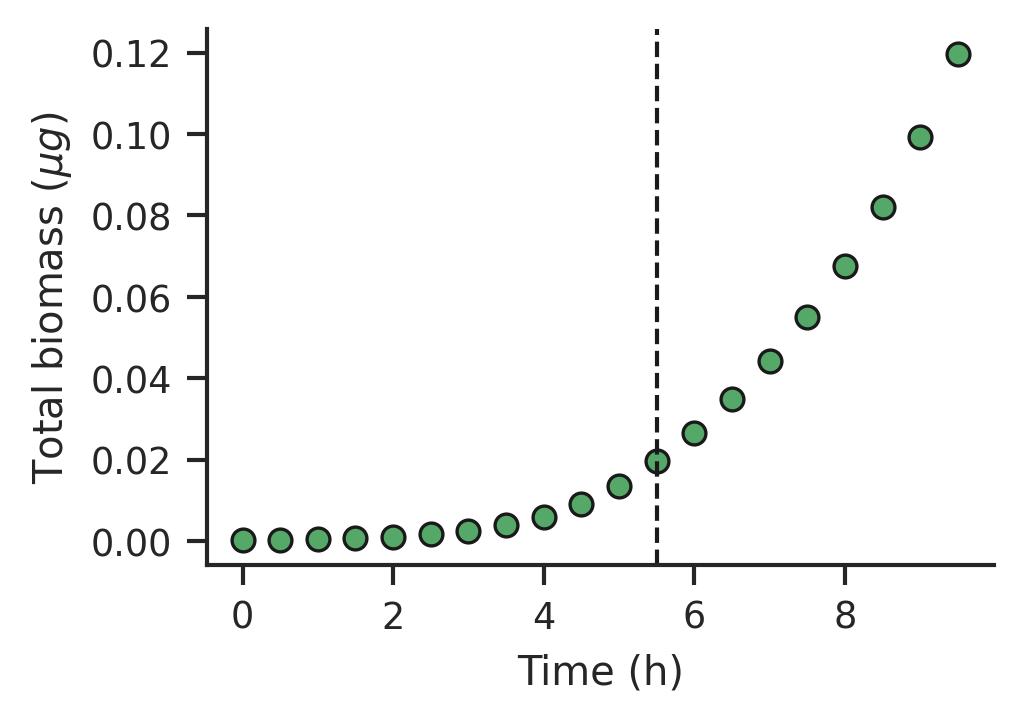

In [99]:
sns.set_theme("paper")
sns.set_style("ticks")

df_growth = df_cells[["time", "total_volume"]]
df_growth = df_growth.groupby("time").agg(
        total=("total_volume", "sum"),
        count=("time", "count")
    ).rename({"total": "biomass"}, axis=1)

CELL_DENSITY = 1.04
df_growth['biomass'] *= CELL_DENSITY * 0.75
df_growth['biomass'] /= 1e6  # convert from picograms to micrograms

# Panel A: total biomass vs. time. Dashed line marks the exponential ->
# sub-exponential transition (T_TRANSITION, from the growth-transition
# diagnostic).
fig, ax = plt.subplots(1, 1, figsize=(3.5, 2.5), dpi=300)
ax.scatter(df_growth.index, df_growth["biomass"], edgecolors='k', s=30, c='g')
ax.axvline(T_TRANSITION, color='k', linestyle='--', lw=1)
ax.set_xlabel(r'Time (h)')
ax.set_ylabel(r'Total biomass ($\mu g$)')
fig.tight_layout()
sns.despine()

save_panel(fig, "panel_A_biomass")

Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_A_biomass_log.svg
Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_A_biomass_log.png


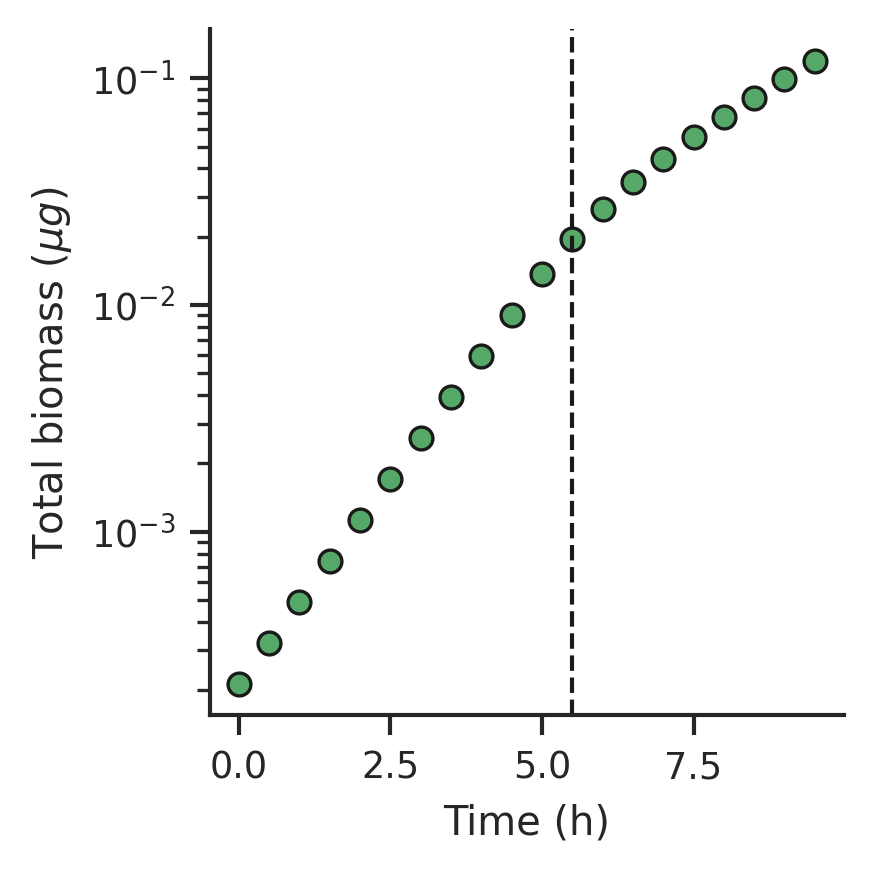

In [100]:
# Panel A (variant, log-scale biomass only): total biomass on a log y-axis,
# to show the exponential -> sub-exponential transition on its own, without
# a second axis. Dashed line marks T_TRANSITION.
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=300)

ax.scatter(df_growth.index, df_growth["biomass"], edgecolors='k', s=30, c='g')
ax.axvline(T_TRANSITION, color='k', linestyle='--', lw=1)
ax.set_xlabel(r'Time (h)')
ax.set_ylabel(r'Total biomass ($\mu g$)')
ax.set_yscale('log')

fig.tight_layout()
sns.despine()

save_panel(fig, "panel_A_biomass_log")

Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_A_biomass_cellcount_linear.svg
Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_A_biomass_cellcount_linear.png


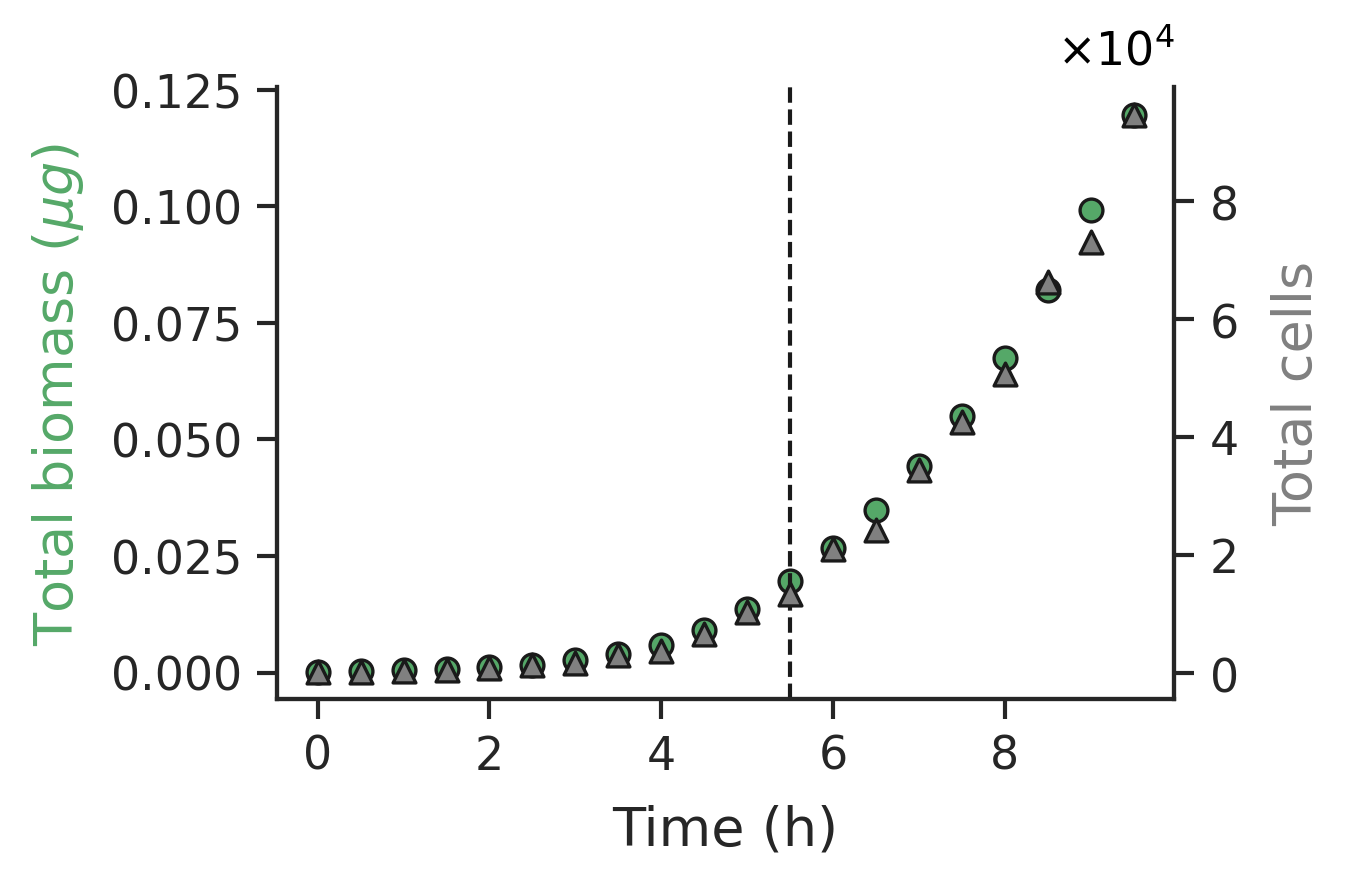

In [ ]:
# Panel A (variant, linear biomass vs. linear cell count): both readouts on
# their natural (non-log) scale, left axis = biomass, right axis = cell
# count, to check by eye whether the two growth curves track each other.
# Dashed line marks T_TRANSITION. Axis label text is colored to match each
# series' marker color (biomass = green, cell count = grey); tick labels
# stay black for readability. Right axis uses scientific notation since
# cell counts run into the thousands and were crowding the plot.
#
# Font sizes are set explicitly here rather than relying on rcParams:
# sns.set_theme("paper") in the panel_A_biomass cell above resets tick/label
# sizes down to seaborn's small "paper" context (that state is global and
# leaks into every cell that runs afterward), which made ticks nearly
# invisible at this figure's proportions.

biomass_color = 'g'
count_color = 'grey'
LABEL_FS = 13
TICK_FS = 11

fig, ax = plt.subplots(1, 1, figsize=(4.5, 3), dpi=300)

ax.scatter(df_growth.index, df_growth["biomass"], edgecolors='k', s=30, c=biomass_color)
ax.axvline(T_TRANSITION, color='k', linestyle='--', lw=1)
ax.set_xlabel(r'Time (h)', fontsize=LABEL_FS, labelpad=6)
ax.set_ylabel(r'Total biomass ($\mu g$)', fontsize=LABEL_FS, color=biomass_color, labelpad=6)
ax.tick_params(axis='x', labelsize=TICK_FS)
ax.tick_params(axis='y', labelsize=TICK_FS)

ax2 = ax.twinx()
ax2.scatter(df_growth.index, df_growth["count"], edgecolors='k', s=30, c=count_color, marker='^')
ax2.set_ylabel(r'Total cells', fontsize=LABEL_FS, color=count_color, labelpad=8)
ax2.tick_params(axis='y', labelsize=TICK_FS)
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0, 0), useMathText=True)

fig.tight_layout()
sns.despine(ax=ax, right=False)
sns.despine(ax=ax2, right=False)

fig.canvas.draw()
offset_str = ax2.yaxis.get_offset_text().get_text()
ax2.yaxis.get_offset_text().set_visible(False)
ax2.text(1.0, 1.02, offset_str, transform=ax2.transAxes,
          ha='right', va='bottom', fontsize=TICK_FS, color='black')

save_panel(fig, "panel_A_biomass_cellcount_linear")

Estimated transition time: t* = 5.5 h
Exponential-phase growth rate   (t < t*):  mu = 0.827 1/h  (doubling time 0.84 h)
Sub-exponential-phase growth rate (t >= t*): mu = 0.444 1/h
Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_A_growth_transition_diagnostic.svg
Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_A_growth_transition_diagnostic.png


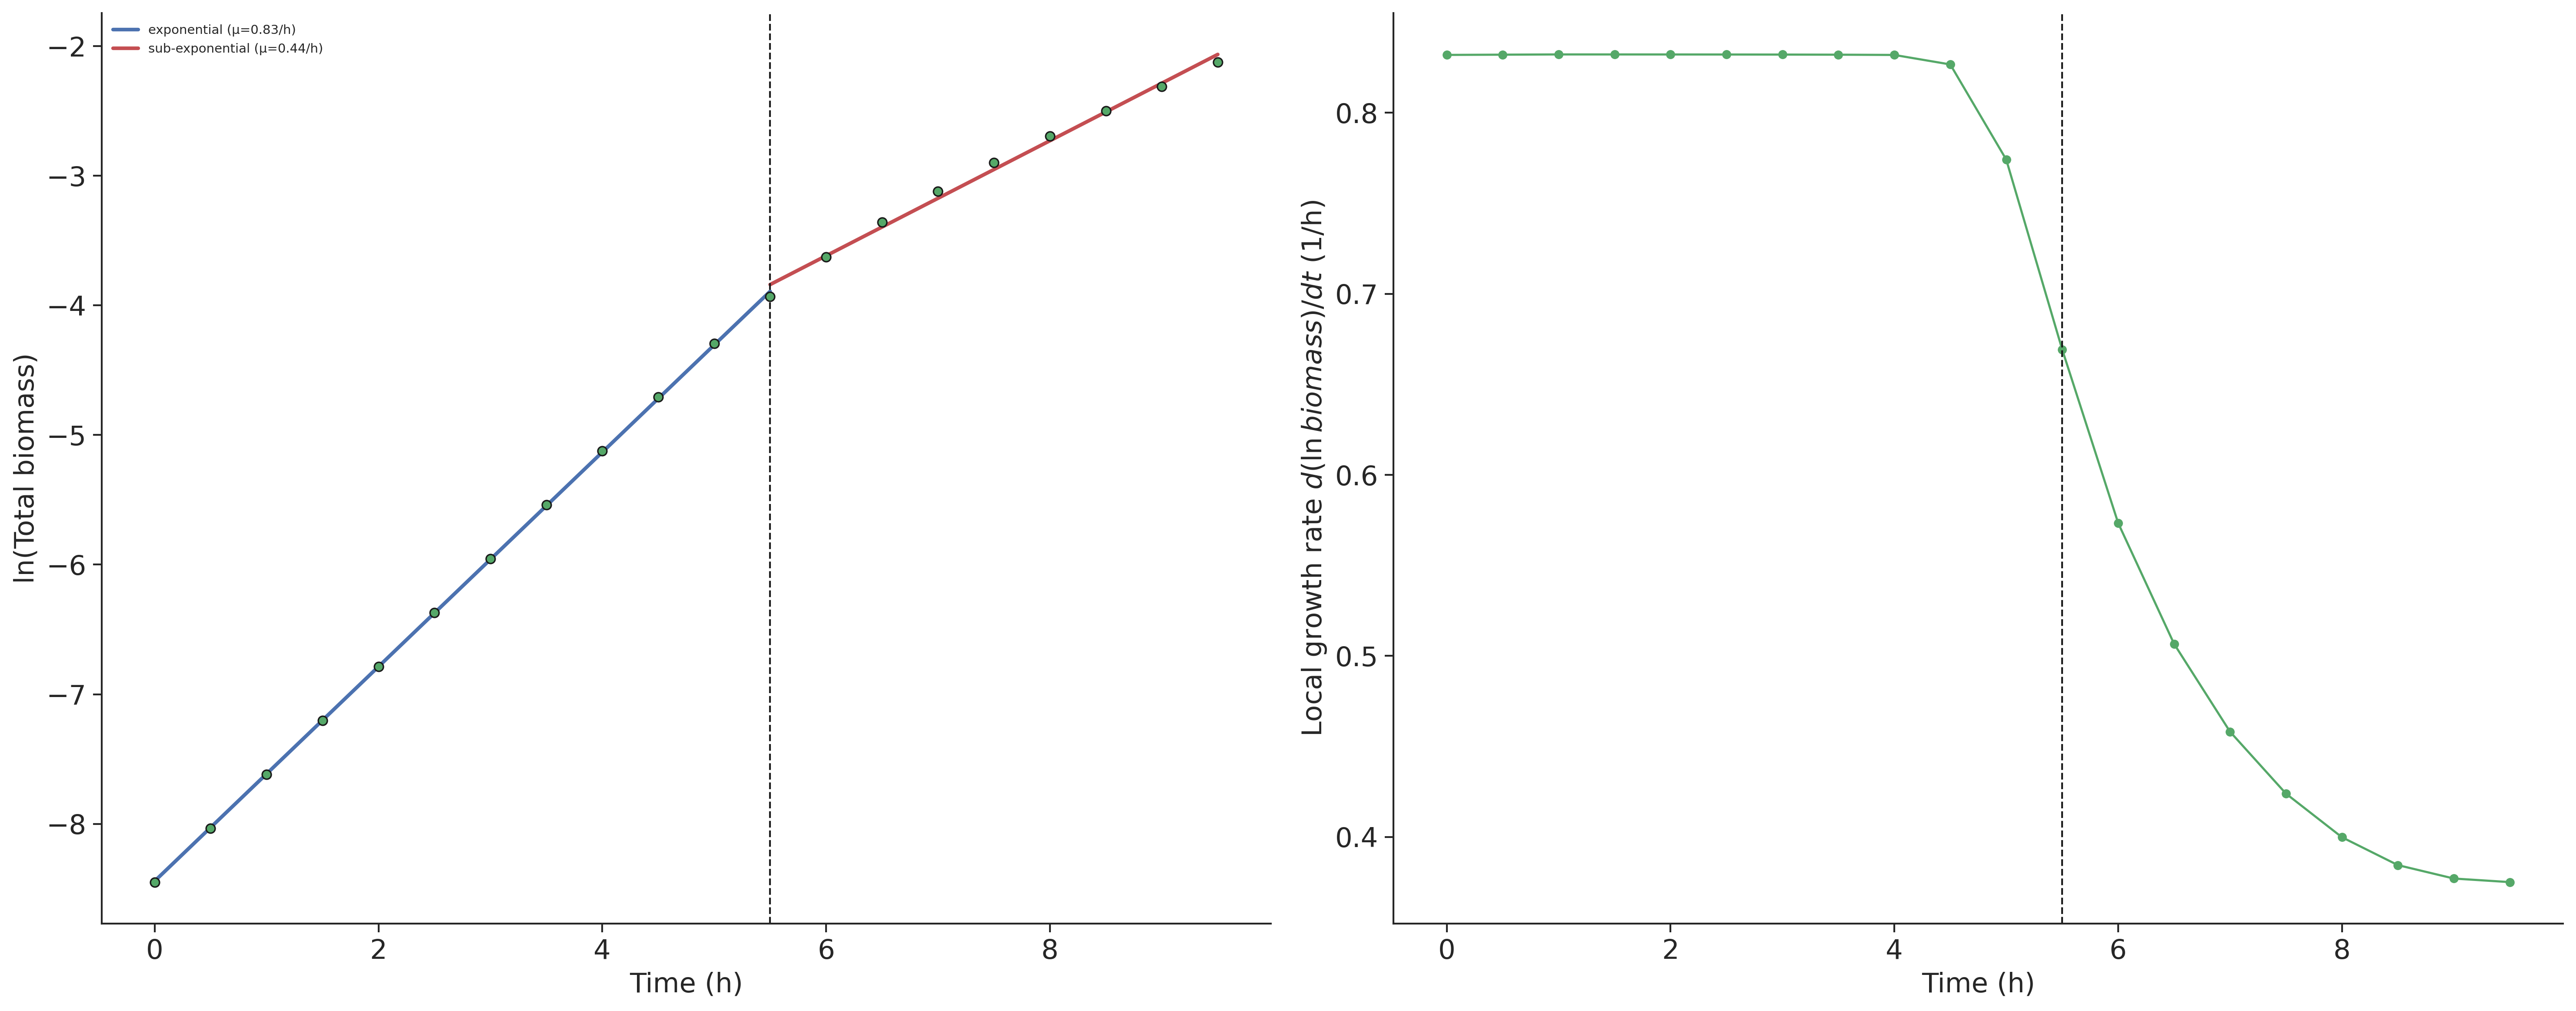

In [ ]:
# Quantify the exponential -> sub-exponential transition in total biomass.
#
# Method 1 (segmented regression): fit two independent linear regressions to
# ln(biomass) vs. time: one "exponential-phase" segment, one
# "sub-exponential-phase" segment, and grid-search over the breakpoint
# index that minimizes the combined residual sum of squares. This gives an
# explicit transition time t* and a growth rate (slope) on each side of it.
#
# Method 2 (model-free cross-check): the local/instantaneous growth rate
# d(ln(biomass))/dt via finite differences. This should sit roughly flat at
# mu_exp during the exponential phase and visibly decline once the colony
# becomes nutrient-limited, independent of assuming any breakpoint model.



t = df_growth.index.values.astype(float)
log_biomass = np.log(df_growth["biomass"].values)

def _fit_segment(t_seg, y_seg):
    X = t_seg.reshape(-1, 1)
    model = LinearRegression().fit(X, y_seg)
    rss = np.sum((y_seg - model.predict(X)) ** 2)
    return model, rss

MIN_SEG_POINTS = 3  # need enough points per segment for a meaningful fit
best = None
for k in range(MIN_SEG_POINTS, len(t) - MIN_SEG_POINTS):
    model1, rss1 = _fit_segment(t[:k + 1], log_biomass[:k + 1])
    model2, rss2 = _fit_segment(t[k:], log_biomass[k:])
    total_rss = rss1 + rss2
    if best is None or total_rss < best[0]:
        best = (total_rss, k, model1, model2)

_, k_break, model_exp, model_sub = best
t_break = t[k_break]
mu_exp = model_exp.coef_[0]
mu_sub = model_sub.coef_[0]

print(f"Estimated transition time: t* = {t_break:.1f} h")
print(f"Exponential-phase growth rate   (t < t*):  mu = {mu_exp:.3f} 1/h  (doubling time {np.log(2) / mu_exp:.2f} h)")
print(f"Sub-exponential-phase growth rate (t >= t*): mu = {mu_sub:.3f} 1/h")

fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=300)

ax = axes[0]
ax.scatter(t, log_biomass, edgecolors='k', s=25, c='g', zorder=3)
t1_fit = np.linspace(t[0], t_break, 20)
t2_fit = np.linspace(t_break, t[-1], 20)
ax.plot(t1_fit, model_exp.predict(t1_fit.reshape(-1, 1)), 'b-', lw=2, label=f'exponential (μ={mu_exp:.2f}/h)')
ax.plot(t2_fit, model_sub.predict(t2_fit.reshape(-1, 1)), 'r-', lw=2, label=f'sub-exponential (μ={mu_sub:.2f}/h)')
ax.axvline(t_break, color='k', linestyle='--', lw=1)
ax.set_xlabel(r'Time (h)')
ax.set_ylabel(r'ln(Total biomass)')
ax.legend(fontsize=7, frameon=False)

ax = axes[1]
local_mu = np.gradient(log_biomass, t)
ax.plot(t, local_mu, 'o-', c='g', ms=4)
ax.axvline(t_break, color='k', linestyle='--', lw=1)
ax.set_xlabel(r'Time (h)')
ax.set_ylabel(r'Local growth rate $d(\ln biomass)/dt$ (1/h)')

fig.tight_layout()
sns.despine()

save_panel(fig, "panel_A_growth_transition_diagnostic")

Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_B_substrates.svg
Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_B_substrates.png


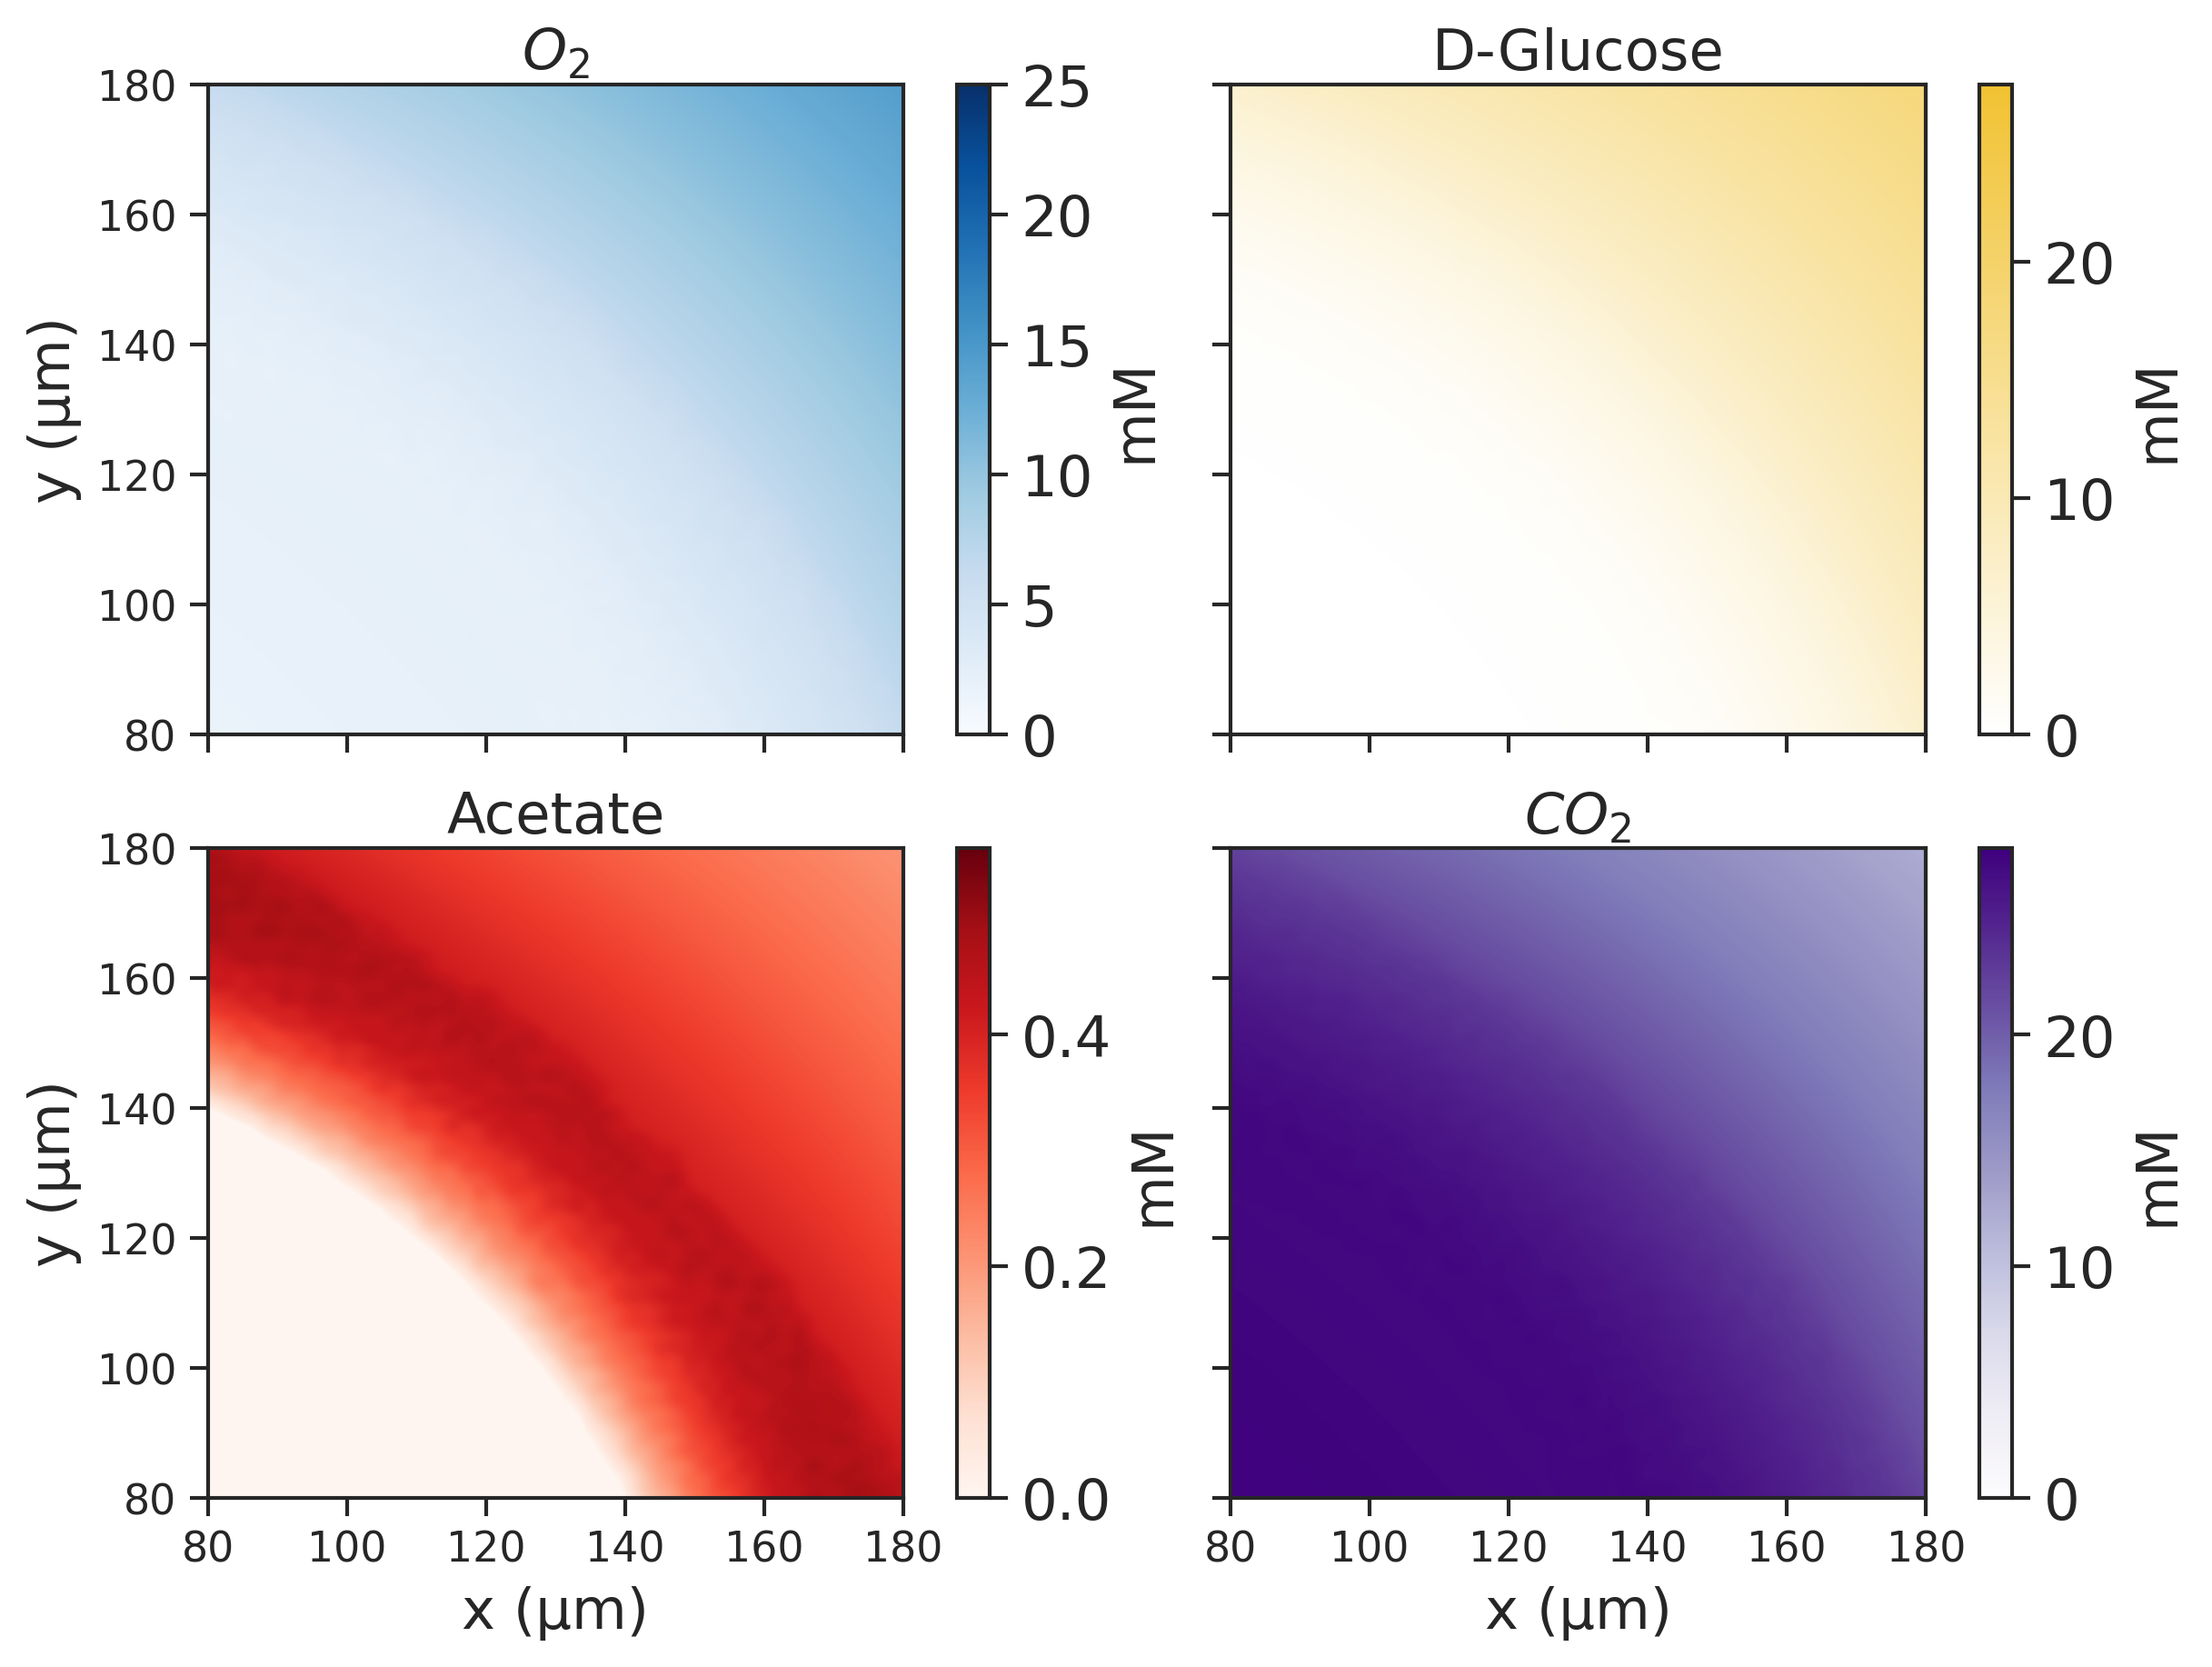

In [ ]:
# Panel B: spatial distribution of extracellular O2, D-glucose, acetate and
# CO2 at 9 hours. time_step=18 lines up with TIME_POINT=9
# so B and C-E depict the same simulation instant.
#
# Panel B gets its own crop window (B_XLIM/B_YLIM) so it can be zoomed
# independently of panels C-E's XLIM/YLIM. Defaults to matching C-E;
# uncomment the line below to reproduce the original full-field crop
# (from the domain corner out to 180 um) instead.


B_XLIM, B_YLIM = XLIM, YLIM
# B_XLIM, B_YLIM = (0, 250), (0, 250)  # original full substrate-field crop

glc_cmap = LinearSegmentedColormap.from_list('yellow', ["#ffffff", "#f1c232ff"])
cmap_dict = {'oxygen': 'Blues', 'glucose': glc_cmap, 'acetate': 'Reds', 'CO2': 'Purples'}
label_dict = {'oxygen': r'$O_2$', 'glucose': 'D-Glucose', 'acetate': 'Acetate', 'CO2': r'$CO_2$'}

z_slice = 0
df_micro = read_microenvironment_step(reader, time_step=18, z_slice=z_slice)

fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 6), sharex=True, sharey=True,
    constrained_layout=True,
    dpi=300
)

axes_flat = np.array(axes).flatten()
i = 0
for (name, units, _) in substrate_info:
    if name == 'lactate':
        continue
    # Pivot: y -> rows, x -> columns
    grid = df_micro.pivot_table(index="y", columns="x", values=name, aggfunc="mean")
    cmap = cmap_dict[name]
    ax = axes_flat[i]
    im = ax.imshow(
        grid.values[:, :],
        origin="lower",
        aspect="auto",
        extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
        cmap=cmap,
        vmin=0,
        vmax=df_micro[name].max(),
        interpolation="bicubic"
    )
    ax.set_xlim(*B_XLIM)
    ax.set_ylim(*B_YLIM)
    ax.set_title(label_dict[name], fontsize=15, pad=4)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=11)
    plt.colorbar(im, ax=ax, label="mM", pad=0.02)
    i += 1

for ax in axes[-1, :]:
    ax.set_xlabel("x (μm)", fontsize=15)
for ax in axes[:, 0]:
    ax.set_ylabel("y (μm)", fontsize=15)

save_panel(fig, "panel_B_substrates")

Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_C_growth_rate.svg
Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_C_growth_rate.png


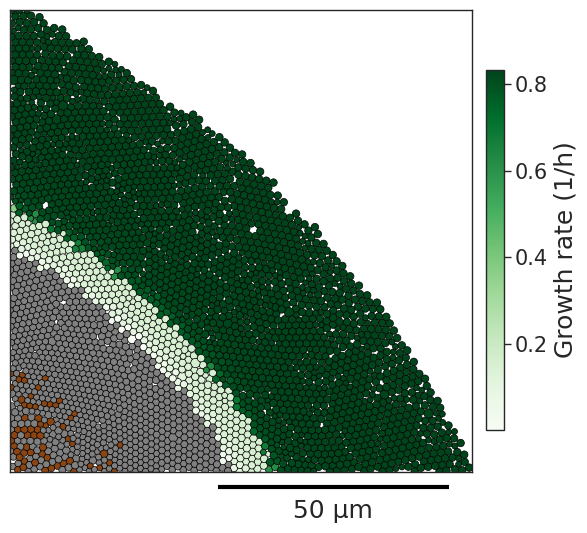

In [31]:
# Panel C: single-cell growth-rate map.
growth_rate_cfg = {
    "value_fn": lambda x: x.growth_rate,
    "cmap": plt.cm.Greens,
    "label": r"Growth rate (1/h)"
}

fig = plot_cells_svg(
    df_cells, time_point=TIME_POINT,
    color_config=growth_rate_cfg,
    xlim=XLIM, ylim=YLIM,
    scale_bar_length=SCALE_BAR_LENGTH,
    skip_dead=False,
    normalize_colors=True,
    edgecolor='black'
)

save_panel(fig, "panel_C_growth_rate")

Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_D_glucose_uptake.svg
Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_D_glucose_uptake.png


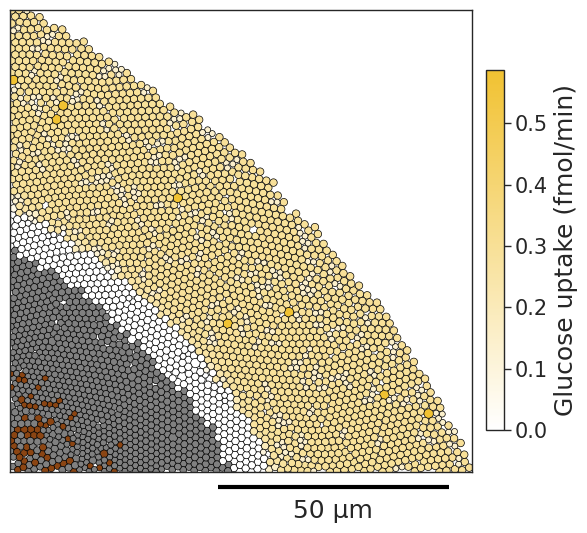

In [21]:
# Panel D: single-cell glucose-uptake map (fmol/min).
glc_uptake_cmap = LinearSegmentedColormap.from_list('yellow', ["#ffffff", "#f1c232ff"])
glucose_uptake_cfg = {
    "value_fn": lambda x: -x.R_EX_glc__D_e * x.total_volume * 0.75 * 1.04 / 60.,
    "cmap": glc_uptake_cmap,
    "label": r"Glucose uptake (fmol/min)"
}

fig = plot_cells_svg(
    df_cells, time_point=TIME_POINT,
    color_config=glucose_uptake_cfg,
    xlim=XLIM, ylim=YLIM,
    scale_bar_length=SCALE_BAR_LENGTH,
    skip_dead=False,
    normalize_colors=True,
    edgecolor='black'
)

save_panel(fig, "panel_D_glucose_uptake")

Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_E_acetate_exchange.svg
Saved /home/oth/BSC/pDFBA/test_parameters_results/colony/fig_folder/panel_E_acetate_exchange.png


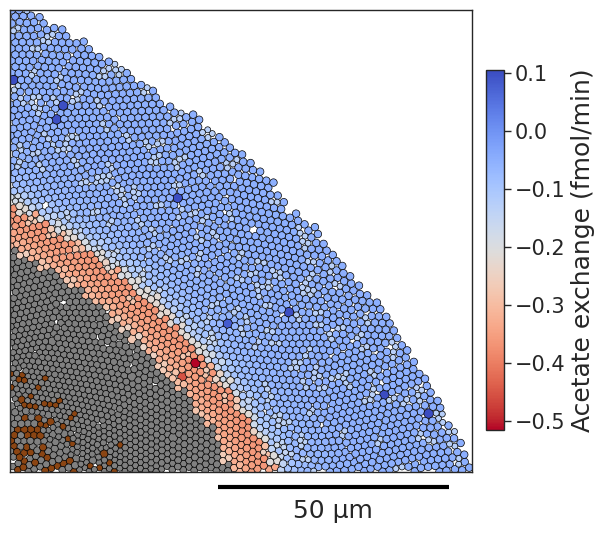

In [22]:
# Panel E: single-cell acetate-exchange map (fmol/min); positive = secretion,
# negative = uptake.
acetate_usage_cfg = {
    "value_fn": lambda x: x.R_EX_ac_e * x.total_volume * 0.75 * 1.04 / 60.,
    "cmap": plt.cm.coolwarm_r,
    "label": r"Acetate exchange (fmol/min)"
}

fig = plot_cells_svg(
    df_cells, time_point=TIME_POINT,
    color_config=acetate_usage_cfg,
    xlim=XLIM, ylim=YLIM,
    scale_bar_length=SCALE_BAR_LENGTH,
    skip_dead=False,
    normalize_colors=True,
    edgecolor='black'
)

save_panel(fig, "panel_E_acetate_exchange")